### Multivariate Linear Regression (다변량 선형 회귀)
- 하나의 종속변수와 여러 독립변수 사이의 관계를 분석하는 기법이다.

In [1]:
import pandas as pd

c_df = pd.read_csv('./datasets/car_purchasing.csv')
c_df

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,USA,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1,57,59729.15130,5358.712177,560304.0671,55915.46248
...,...,...,...,...,...,...,...,...,...
495,Walter,ligula@Cumsociis.ca,USA,0,41,71942.40291,6995.902524,541670.1016,48901.44342
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,USA,1,38,56039.49793,12301.456790,360419.0988,31491.41457
497,Pearl,penatibus.et@massanonante.com,USA,1,54,68888.77805,10611.606860,764531.3203,64147.28888
498,Nell,Quisque.varius@arcuVivamussit.net,USA,1,59,49811.99062,14013.034510,337826.6382,45442.15353


In [2]:
c_df.columns

Index(['Customer Name', 'Customer e-mail', 'Country', 'Gender', 'Age',
       'Annual Salary', 'Credit Card Debt', 'Net Worth',
       'Car Purchase Amount'],
      dtype='object')

In [3]:
columns = ['Gender', 'Age', 'Annual Salary', 'Credit Card Debt', 'Net Worth', 'Car Purchase Amount']
pre_c_df = c_df[columns]
pre_c_df

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57,59729.15130,5358.712177,560304.0671,55915.46248
...,...,...,...,...,...,...
495,0,41,71942.40291,6995.902524,541670.1016,48901.44342
496,1,38,56039.49793,12301.456790,360419.0988,31491.41457
497,1,54,68888.77805,10611.606860,764531.3203,64147.28888
498,1,59,49811.99062,14013.034510,337826.6382,45442.15353


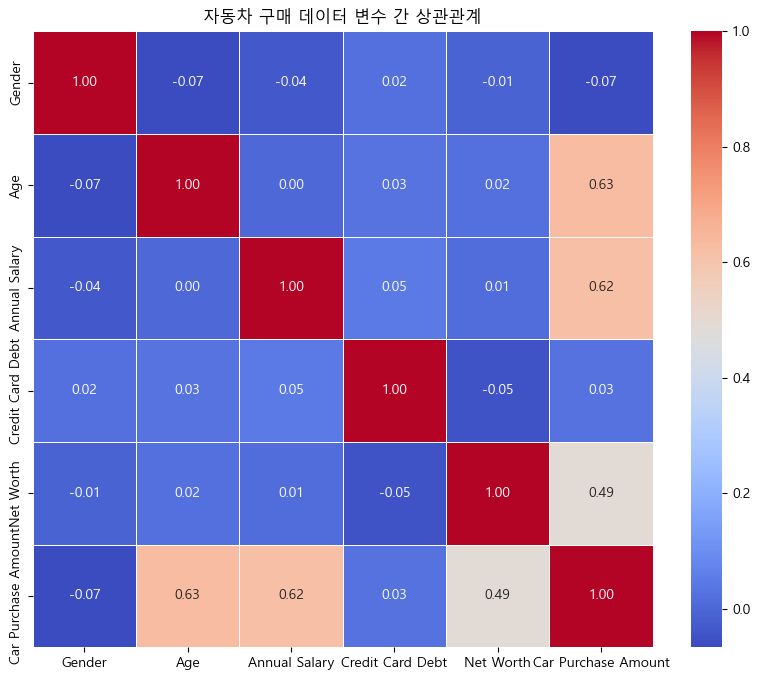

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 상관계수 계산
corr = pre_c_df.corr()

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('자동차 구매 데이터 변수 간 상관관계')
plt.show()

array([[<Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Annual Salary'}>,
        <Axes: title={'center': 'Credit Card Debt'}>],
       [<Axes: title={'center': 'Net Worth'}>,
        <Axes: title={'center': 'Car Purchase Amount'}>]], dtype=object)

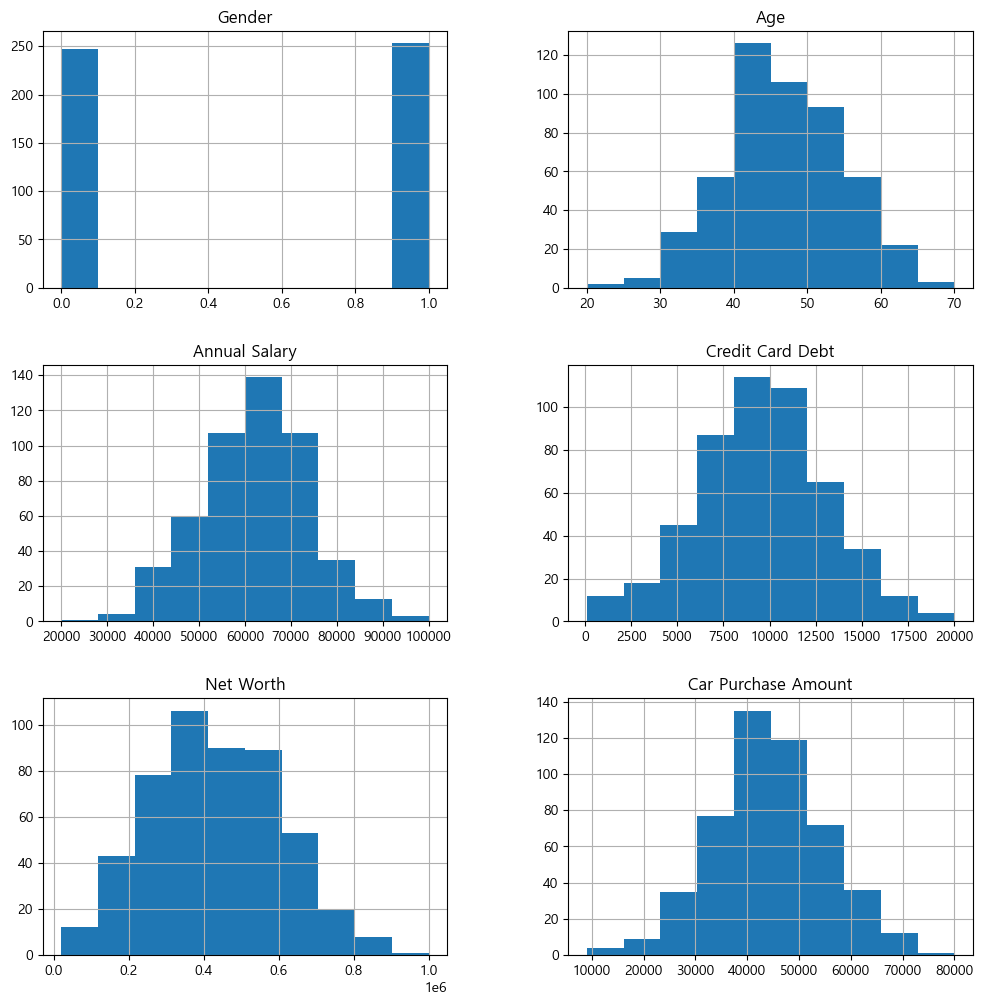

In [6]:
pre_c_df.hist(figsize=(12, 12))

In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

feature = pre_c_df[['Age', 'Annual Salary', 'Net Worth']]
target = pre_c_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, random_state=124)

l_r = LinearRegression()
l_r.fit(X_train, y_train)
print('W1: {:.4f}, W2: {:.4f}, W3: {:.4f} b: {:.4f}'\
      .format(l_r.coef_[0], l_r.coef_[1], l_r.coef_[2], l_r.intercept_))

W1: 839.5635, W2: 0.5613, W3: 0.0289 b: -41939.7325


In [10]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

def get_evaluation(y_test, prediction):
    MAE =  mean_absolute_error(y_test, prediction)
    MSE = mean_squared_error(y_test, prediction)
    RMSE = np.sqrt(MSE)
    MSLE = mean_squared_log_error(y_test, prediction)
    RMSLE = np.sqrt(mean_squared_log_error(y_test, prediction))
    R2 = r2_score(y_test, prediction)

    print('MAE: {:.4f}, MSE: {:.4f}, RMSE: {:.4f}, MSLE: {:.4f}, RMSLE: {:.4f}, R2: {:.4f}'.format(MAE, MSE, RMSE, MSLE, RMSLE, R2))

In [11]:
get_evaluation(y_test, l_r.predict(X_test))

MAE: 195.3257, MSE: 55726.6310, RMSE: 236.0649, MSLE: 0.0000, RMSLE: 0.0060, R2: 0.9995


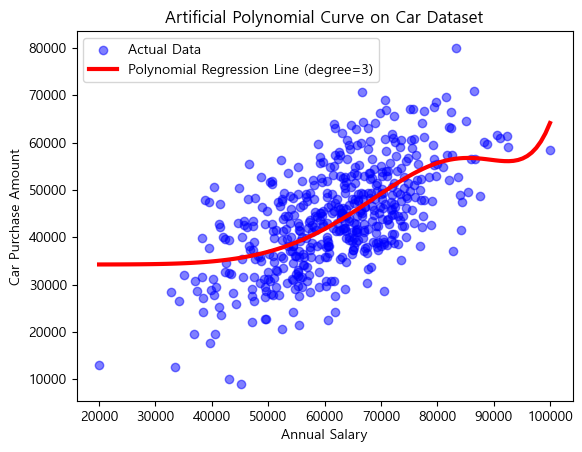

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# 시각화를 위해 변수 하나(연봉)만 사용
X_salary = feature[['Annual Salary']] 

# 1. 다항 회귀 변환 (10차식)
poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X_salary.values)

# 2. 모델 학습
l_r_poly = LinearRegression()
l_r_poly.fit(X_poly, target)

# 3. 매끄러운 곡선을 그리기 위한 임의의 데이터 생성
x_range = np.linspace(X_salary.min(), X_salary.max(), 100).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_ped_poly = l_r_poly.predict(x_range_poly)

# 4. 시각화
plt.scatter(X_salary, target, color='blue', alpha=0.5, label='Actual Data')
plt.plot(x_range, y_ped_poly, color='red', linewidth=3, label='Polynomial Regression Line (degree=3)') # 이게 곡선입니다!
plt.xlabel('Annual Salary')
plt.ylabel('Car Purchase Amount')
plt.title('Artificial Polynomial Curve on Car Dataset')
plt.legend()
plt.show()

In [16]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

feature = pre_c_df[['Age', 'Annual Salary', 'Net Worth']]
target = pre_c_df.iloc[:, -1]

X_train, X_test, y_train, y_test = \
train_test_split(feature, target, test_size=0.2, random_state=124)

poly = PolynomialFeatures(degree=3)
X_train = poly.fit_transform(X_train.values)
X_test = poly.transform(X_test.values)

l_r_poly = LinearRegression()
l_r_poly.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
get_evaluation(y_test, l_r_poly.predict(X_test))

MAE: 268.8200, MSE: 145824.4481, RMSE: 381.8697, MSLE: 0.0003, RMSLE: 0.0162, R2: 0.9987


##### 다중 공선성(Multicollinearity)
- 회귀분석에서 독립변수들 간에 강한 상관관계가 나타나는 문제를 의미한다.
<img src="./images/multicollinearity.png" style="margin-left: 0">

##### VIF(Variance Inflation Factor)
- 분산 팽창 요인 수치가 5 미만이면 양호, 10 이상일 경우 다중 공선성의 문제가 있다는 뜻이다.
- 공분산은 두 변수가 같이 움직이는 정도이고, VIF는 그 공분산이 너무 커서 모델이 헷갈려 하는 정도를 숫자로 보여준다.

In [19]:
%pip install statsmodels

  Using cached statsmodels-0.14.6-cp310-cp310-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp310-cp310-win_amd64.whl (9.6 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [st

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF < 5: 매우 양호 (독립성이 높음)
# VIF < 10: 수용 가능 (약간의 상관관계가 있으나 문제없음)
# VIF > 10: 위험 (다중공선성 존재, 변수 제거 또는 처리가 필요함)
# 만약 어떤 변수의 VIF가 20 ~ 30이라면, 그 변수는 빼거나 다른 것과 합쳐서 해결한다.
def feature_engineering_VIF(features):
    vif = pd.DataFrame()
    vif['vif_score'] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
    vif['feature'] = features.columns
    return vif

In [21]:
feature_engineering_VIF(feature)

,vif_score,feature
0,17.815260,Age
1,17.260300,Annual Salary
2,6.646324,Net Worth


#### Feature Enginnering

In [22]:
pre1_c_df = pre_c_df.copy()

In [23]:
# Salary_per_Age: 나이를 한 살 먹을 때마다 벌어들이는 소득
pre1_c_df['Salary_per_Age'] = pre_c_df['Annual Salary'] / pre_c_df['Age']
pre1_c_df

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount,Salary_per_Age
0,0,42,62812.09301,11609.380910,238961.2505,35321.45877,1495.526024
1,0,41,66646.89292,9572.957136,530973.9078,45115.52566,1625.533974
2,1,43,53798.55112,11160.355060,638467.1773,42925.70921,1251.129096
3,1,58,79370.03798,14426.164850,548599.0524,67422.36313,1368.448931
4,1,57,59729.15130,5358.712177,560304.0671,55915.46248,1047.879847
...,...,...,...,...,...,...,...
495,0,41,71942.40291,6995.902524,541670.1016,48901.44342,1754.692754
496,1,38,56039.49793,12301.456790,360419.0988,31491.41457,1474.723630
497,1,54,68888.77805,10611.606860,764531.3203,64147.28888,1275.718112
498,1,59,49811.99062,14013.034510,337826.6382,45442.15353,844.271027


In [24]:
pre1_c_df.drop(['Age', 'Annual Salary'], axis=1, inplace=True)

In [25]:
pre1_c_df

,Gender,Credit Card Debt,Net Worth,Car Purchase Amount,Salary_per_Age
0,0,11609.380910,238961.2505,35321.45877,1495.526024
1,0,9572.957136,530973.9078,45115.52566,1625.533974
2,1,11160.355060,638467.1773,42925.70921,1251.129096
3,1,14426.164850,548599.0524,67422.36313,1368.448931
4,1,5358.712177,560304.0671,55915.46248,1047.879847
...,...,...,...,...,...
495,0,6995.902524,541670.1016,48901.44342,1754.692754
496,1,12301.456790,360419.0988,31491.41457,1474.723630
497,1,10611.606860,764531.3203,64147.28888,1275.718112
498,1,14013.034510,337826.6382,45442.15353,844.271027


In [26]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

features = pre1_c_df[['Salary_per_Age', 'Net Worth']]
targets = pre1_c_df['Car Purchase Amount']

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, test_size=0.2, random_state=124)

poly = PolynomialFeatures(degree=3)
X_train = poly.fit_transform(X_train.values)
X_test = poly.transform(X_test.values)

l_r_poly = LinearRegression()
l_r_poly.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
get_evaluation(y_test, l_r_poly.predict(X_test))

MAE: 7443.2877, MSE: 84923921.4039, RMSE: 9215.4176, MSLE: 0.0648, RMSLE: 0.2545, R2: 0.2297


In [28]:
feature_engineering_VIF(features)

,vif_score,feature
0,5.072286,Salary_per_Age
1,5.072286,Net Worth


In [29]:
pre2_c_df = pre_c_df.copy()

In [30]:
pre2_c_df = pre_c_df[['Annual Salary', 'Net Worth', 'Car Purchase Amount']]

In [31]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

features = pre2_c_df[['Annual Salary', 'Net Worth']]
targets = pre2_c_df['Car Purchase Amount']

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, test_size=0.2, random_state=124)

poly = PolynomialFeatures(degree=3)
X_train = poly.fit_transform(X_train.values)
X_test = poly.transform(X_test.values)

l_r_poly = LinearRegression()
l_r_poly.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
get_evaluation(y_test, l_r_poly.predict(X_test))

MAE: 5252.7974, MSE: 44688597.4993, RMSE: 6684.9531, MSLE: 0.0362, RMSLE: 0.1904, R2: 0.5946


In [33]:
feature_engineering_VIF(features)

,vif_score,feature
0,6.002813,Annual Salary
1,6.002813,Net Worth


In [34]:
pre3_c_df = pre_c_df.copy()

In [35]:
# Salary_Age: 나이가 많아짐에 따라 연봉이 자산에 미치는 영향력의 변화
pre3_c_df['Salary_Age'] = pre_c_df['Annual Salary'] * pre_c_df['Age']
pre3_c_df

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount,Salary_Age
0,0,42,62812.09301,11609.380910,238961.2505,35321.45877,2.638108e+06
1,0,41,66646.89292,9572.957136,530973.9078,45115.52566,2.732523e+06
2,1,43,53798.55112,11160.355060,638467.1773,42925.70921,2.313338e+06
3,1,58,79370.03798,14426.164850,548599.0524,67422.36313,4.603462e+06
4,1,57,59729.15130,5358.712177,560304.0671,55915.46248,3.404562e+06
...,...,...,...,...,...,...,...
495,0,41,71942.40291,6995.902524,541670.1016,48901.44342,2.949639e+06
496,1,38,56039.49793,12301.456790,360419.0988,31491.41457,2.129501e+06
497,1,54,68888.77805,10611.606860,764531.3203,64147.28888,3.719994e+06
498,1,59,49811.99062,14013.034510,337826.6382,45442.15353,2.938907e+06


In [36]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

features = pre3_c_df[['Salary_Age', 'Net Worth']]
targets = pre3_c_df['Car Purchase Amount']

X_train, X_test, y_train, y_test = \
train_test_split(features, targets, test_size=0.2, random_state=124)

poly = PolynomialFeatures(degree=3)
X_train = poly.fit_transform(X_train.values)
X_test = poly.transform(X_test.values)

l_r_poly = LinearRegression()
l_r_poly.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
get_evaluation(y_test, l_r_poly.predict(X_test))

MAE: 903.2258, MSE: 2012513.8366, RMSE: 1418.6310, MSLE: 0.0037, RMSLE: 0.0605, R2: 0.9817


In [38]:
feature_engineering_VIF(features)

,vif_score,feature
0,5.338816,Salary_Age
1,5.338816,Net Worth


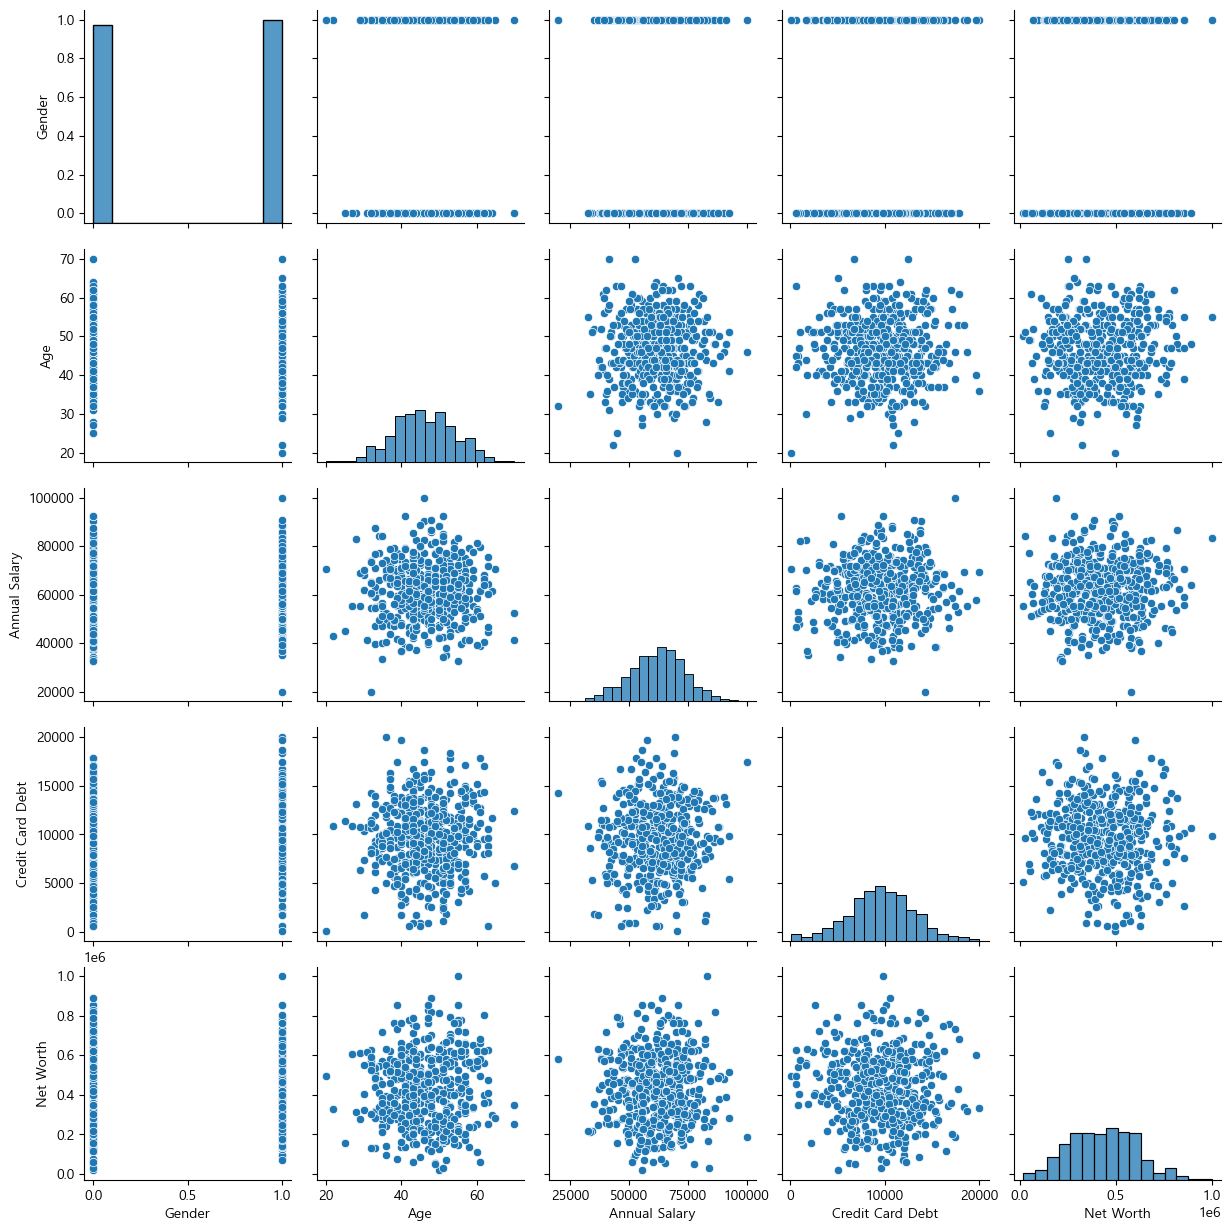

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(pre_c_df.iloc[:, :-1])
plt.show()